In [1]:
%load_ext autoreload
%autoreload 2

# Test classifier by comparing to all-GCL data

Batch effects are expected, but they shouldn't be too large

## Load Classifier

We first load the classifier and the Baden 2016 data, and compare the predictions of the classifier to the stored values.

In [2]:
import numpy as np

from gcl_classifier.model import get_model
from gcl_classifier.classifier import extract_features
from gcl_classifier.data import get_data, prepare_baden_data

In [3]:
classifier_model = get_model()
classifier_model

Loading model (downloading if needed)...
✓ Model loaded successfully


,estimator,RandomForestC...dom_state=765)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,n_estimators,600
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0


In [4]:
data = get_data()
baden_data_16 = prepare_baden_data(data['baden_mat'])

Loading data (downloading if needed)...
✓ Data loaded successfully


In [6]:
X_16, feature_names = extract_features(
    preproc_chirps=baden_data_16['chirp_traces'],
    preproc_bars=baden_data_16['bar_traces'],
    bar_ds_pvalues=baden_data_16['bar_dp'],
    roi_size_um2s=baden_data_16['roi_size_um2'],
    chirp_features=data["chirp_feats"],
    bar_features=data["bar_feats"],
)

In [7]:
predictions = classifier_model.predict(X_16)

correct = np.sum(baden_data_16["cluster_labels"] == predictions)
print(f"Matching predictions: {correct} ({correct/X_16.shape[0]:.1%}), "
      f"mismatching predictions: {predictions.shape[0] - correct} ({(X_16.shape[0] - correct) / X_16.shape[0]:.1%})")

Matching predictions: 7930 (99.4%), mismatching predictions: 49 (0.6%)


Most of the celltype predictions match. The small number of mismatched predictions is expected as the classifier was re-trained.

## Download GCL Data

We download the GCL datoa in the folder `../data`, feel free to adapt this code depending on your preferred location.
Make sure that you installed this package with the additonal notebook dependences (e.g by using `pip install "gcl_classifier[notebook]"`)

In [8]:
# download data into data folder

! hf download --repo-type dataset eulerlab/all-gcl --local-dir ../data


Fetching 1695 files: 100%|█████████████████| 1695/1695 [00:01<00:00, 929.94it/s]
Download complete: : 0.00B [00:01, ?B/s]              /home/tzenkel/GitRepos/gcl_classifier/data
Download complete: : 0.00B [00:01, ?B/s]


In [9]:
import pandas as pd
import os

dataset_path = "../data"

all_gcl_df = pd.read_parquet(os.path.join(dataset_path, "all_GCL_table.parquet"))


In [10]:
# from https://github.com/eulerlab/all-GCL-manuscript/blob/e2963b1fe9cb012e62c8e4ef1b0c9dd25897a757/all_GCL/utils.py#L58
def restore_numpy_arrays(df):
    """Automatically detect and restore numpy arrays from nested structures."""
    df_restored = df.copy()

    def is_nested_array_structure(val):
        """Check if a value is a nested array structure that should be converted to numpy array."""

        # Check for numpy object arrays containing other arrays (from parquet loading)
        if isinstance(val, np.ndarray) and val.dtype == object and val.size > 0:
            flat_val = val.flatten()
            for item in flat_val:
                if isinstance(item, (np.ndarray, list)):
                    return True

        # Check for nested lists
        if isinstance(val, list) and len(val) > 0 and isinstance(val[0], (list, np.ndarray)):
            return True

        return False

    def convert_to_numpy_array(val):
        """Convert nested structure to proper numpy array."""

        # Handle numpy object arrays (from parquet)
        if isinstance(val, np.ndarray) and val.dtype == object:
            # Try to stack the arrays inside
            try:
                return np.stack(val)
            except Exception:
                # If stacking fails, convert to list first then to array
                try:
                    nested_list = [item.tolist() if isinstance(item, np.ndarray) else item for item in val]
                    return np.array(nested_list)
                except Exception:
                    return val

        # Handle nested lists
        if isinstance(val, list):
            try:
                return np.array(val)
            except Exception:
                return val

        if val is None or pd.isna(val):
            return val

        return val

    for col in df_restored.columns:
        if df_restored[col].dtype == "object":
            # Check if this column contains nested array structures
            sample_non_null = df_restored[col].dropna()
            if len(sample_non_null) > 0:
                first_val = sample_non_null.iloc[0]
                if is_nested_array_structure(first_val):
                    print(f"Restoring numpy arrays in column: {col}")
                    df_restored[col] = df_restored[col].apply(convert_to_numpy_array)

    return df_restored

In [11]:
all_gcl_df = restore_numpy_arrays(all_gcl_df)

Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: srf


We now loaded the data into a dataframe, let's filter it to contain only the first controll experiment containing high quality ventral cells.

In [12]:
required_fields = ["experimenter", "preproc_bar", "preproc_chirp", "bar_ds_pvalue", "roi_size_um2"]
# restrict to HQ fields 
restricted_df = all_gcl_df[
    (all_gcl_df["cond1"].str.lower().isin(["c1", "control"])) &  # only the first control experiment
    (all_gcl_df["genline"] == "Bl6") &  # only specific genline
    (all_gcl_df["chirp_qidx"] > 0.45) | (all_gcl_df["bar_qidx"] > 0.6) &  # only high quality fields
    (all_gcl_df["ventral_dorsal_pos_um"] < -200) &  # only ventral ROIs
    (all_gcl_df["temporal_nasal_pos_um"] > -1300)  # that are not too far off
][required_fields]

print(f"Filtered dataframe from {len(all_gcl_df)} to {len(restricted_df)} cells ({len(restricted_df)/len(all_gcl_df):.1%}).")

Filtered dataframe from 84756 to 36836 cells (43.5%).


Based on this filtered All GCL (2025) dataframe, we extract the features and combine them with the Baden (2016) data.

In [13]:
preproc_chirps_25 = np.vstack(restricted_df["preproc_chirp"])
preproc_bars_25 = np.vstack(restricted_df["preproc_bar"])
bar_dps_25 = np.array(restricted_df["bar_ds_pvalue"])
roi_size_um2s_25 = np.array(restricted_df["roi_size_um2"])

X_25, _ = extract_features(
    preproc_chirps=preproc_chirps_25, preproc_bars=preproc_bars_25, bar_ds_pvalues=bar_dps_25,
    roi_size_um2s=roi_size_um2s_25, chirp_features=data["chirp_feats"], bar_features=data["bar_feats"])

X_combo = np.vstack([X_16, X_25])
dataset_combo = ['16'] * X_16.shape[0] + ['v2'] * X_25.shape[0]

## Checking Batch Effects

Now let's check if we can see any batch effects between the datasources, and between different experimenters.
We do this by comparing feature distributions by dataset, and by plotting a TSNE. Lateron, we will also train new classifiers based on 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_combo_scaled = scaler.fit_transform(X_combo)

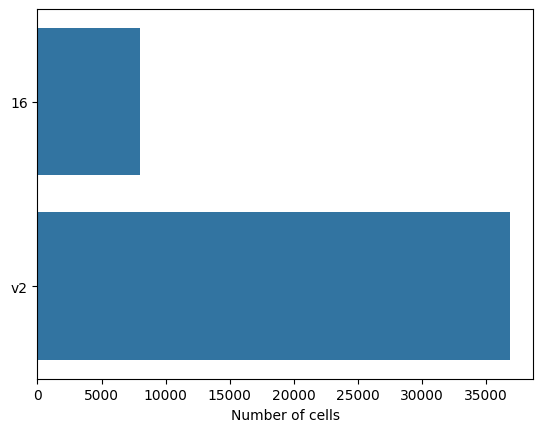

In [16]:
sns.countplot(dataset_combo)
plt.xlabel("Number of cells")
plt.show()

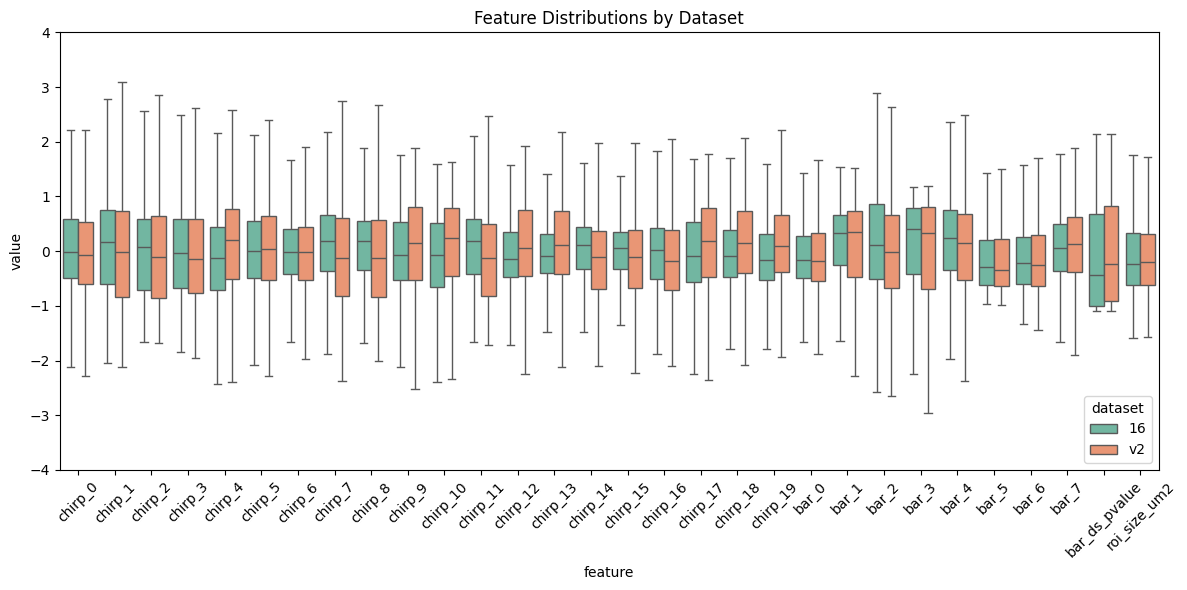

In [17]:
df = pd.DataFrame(X_combo_scaled, columns=feature_names)
df['dataset'] = dataset_combo

df_melt = df.melt(id_vars='dataset', var_name='feature', value_name='value')

plt.figure(figsize=(12, 6))
sns.boxplot(x='feature', y='value', hue='dataset', data=df_melt, fliersize=0, palette='Set2')
plt.title('Feature Distributions by Dataset')
plt.xticks(rotation=45)
plt.ylim(-4, +4)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
X_combo_tsne = tsne.fit_transform(X_combo_scaled)

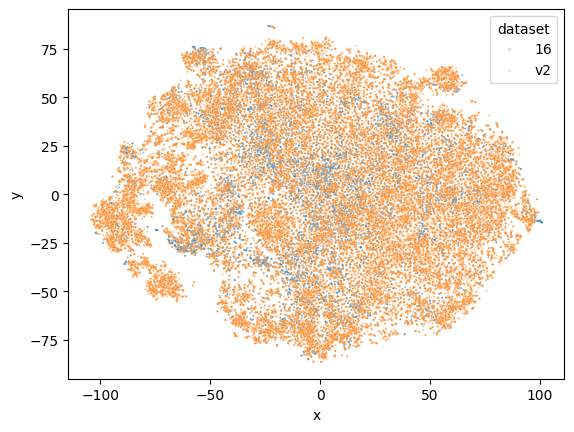

In [19]:
df_combo_tsne = pd.DataFrame({'x': X_combo_tsne[:, 0], 'y': X_combo_tsne[:, 1], 'dataset': dataset_combo})

sns.scatterplot(data=df_combo_tsne, x='x', y='y', hue='dataset', alpha=0.5, s=2)
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


def check_batch_effects(X, y, feature_names=None):
    """
    Analyze feature importance using Random Forest classifier
    
    Parameters:
    X: Feature matrix
    y: Target variable
    feature_names: List of feature names (optional)
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train Random Forest classifier
    clf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
    )
    clf.fit(X_train, y_train)

    # Make predictions and evaluate
    y_pred = clf.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Feature importance analysis
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]  # sort descending

    # Create feature importance plot
    plt.figure(figsize=(12, 6))
    plt.title("Feature Importance")

    # Use feature names if provided, otherwise use indices
    if feature_names is not None:
        labels = [feature_names[i] for i in indices]
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), labels, rotation=45, ha='right')
    else:
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), [f'Feature {i}' for i in indices], rotation=45, ha='right')

    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.tight_layout()
    plt.show()

Accuracy: 0.8467031127970546

Classification Report:
               precision    recall  f1-score   support

          16       0.76      0.20      0.32      1596
          v2       0.85      0.99      0.91      7367

    accuracy                           0.85      8963
   macro avg       0.81      0.59      0.62      8963
weighted avg       0.83      0.85      0.81      8963



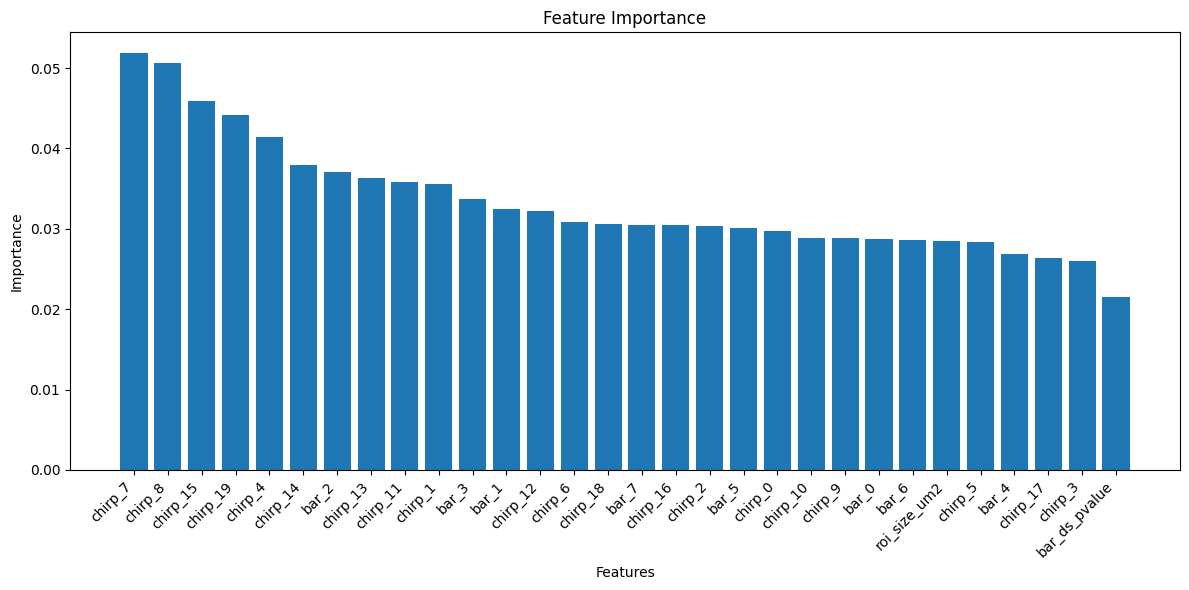

In [21]:
check_batch_effects(X=X_combo, y=dataset_combo, feature_names=feature_names)

['Experimenter 2' 'Experimenter 4' 'Experimenter 8' 'Experimenter 3'
 'Experimenter 5' 'Experimenter 1' 'Experimenter 7' 'Experimenter 6']


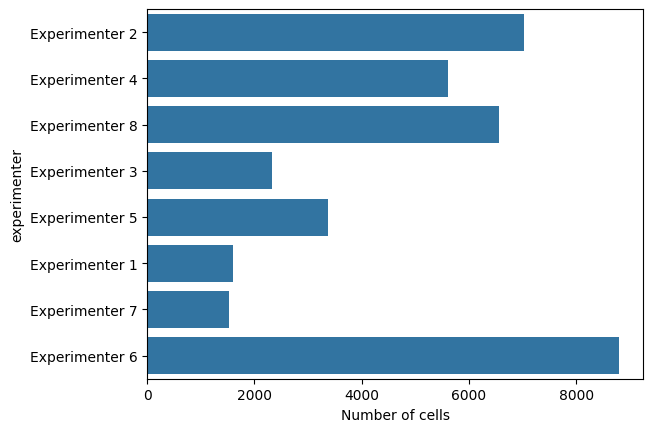

In [22]:
experimenter_25 = restricted_df["experimenter"]
sns.countplot(experimenter_25)
plt.xlabel("Number of cells")
print(experimenter_25.unique())

Accuracy: 0.7284768211920529

Classification Report:
                 precision    recall  f1-score   support

Experimenter 2       0.72      0.77      0.75      1405
Experimenter 8       0.74      0.68      0.71      1313

      accuracy                           0.73      2718
     macro avg       0.73      0.73      0.73      2718
  weighted avg       0.73      0.73      0.73      2718



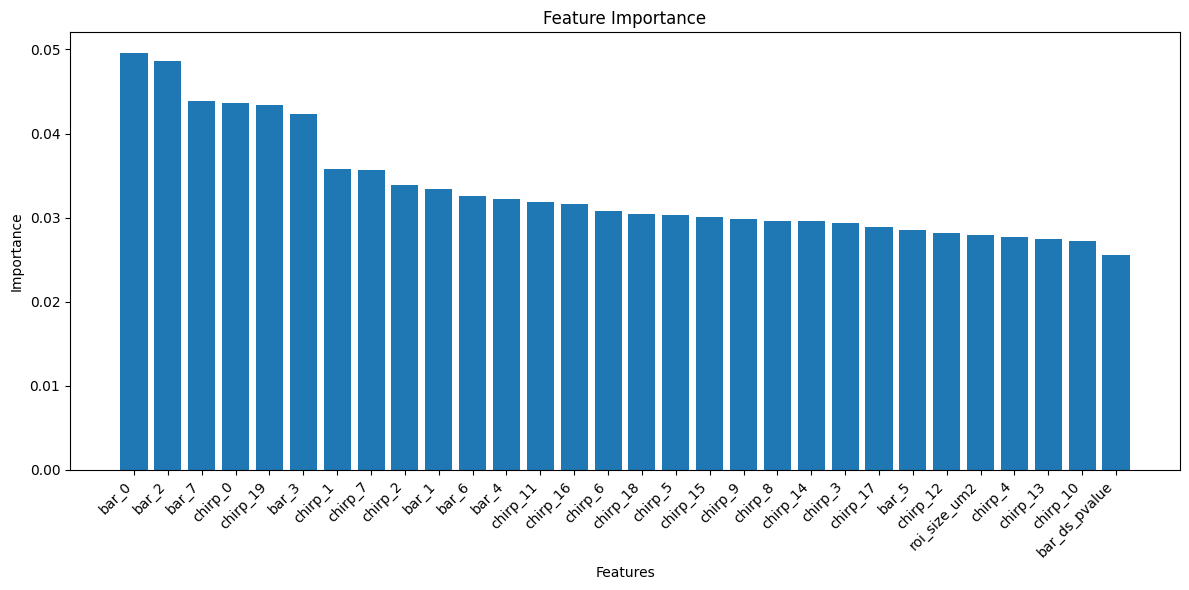

In [23]:
idxs = (experimenter_25 == 'Experimenter 8') | (experimenter_25 == 'Experimenter 2')
check_batch_effects(X=X_25[idxs], y=experimenter_25[idxs], feature_names=feature_names)

Accuracy: 0.7437027707808564

Classification Report:
                 precision    recall  f1-score   support

Experimenter 3       0.68      0.25      0.36       467
Experimenter 4       0.75      0.95      0.84      1121

      accuracy                           0.74      1588
     macro avg       0.71      0.60      0.60      1588
  weighted avg       0.73      0.74      0.70      1588



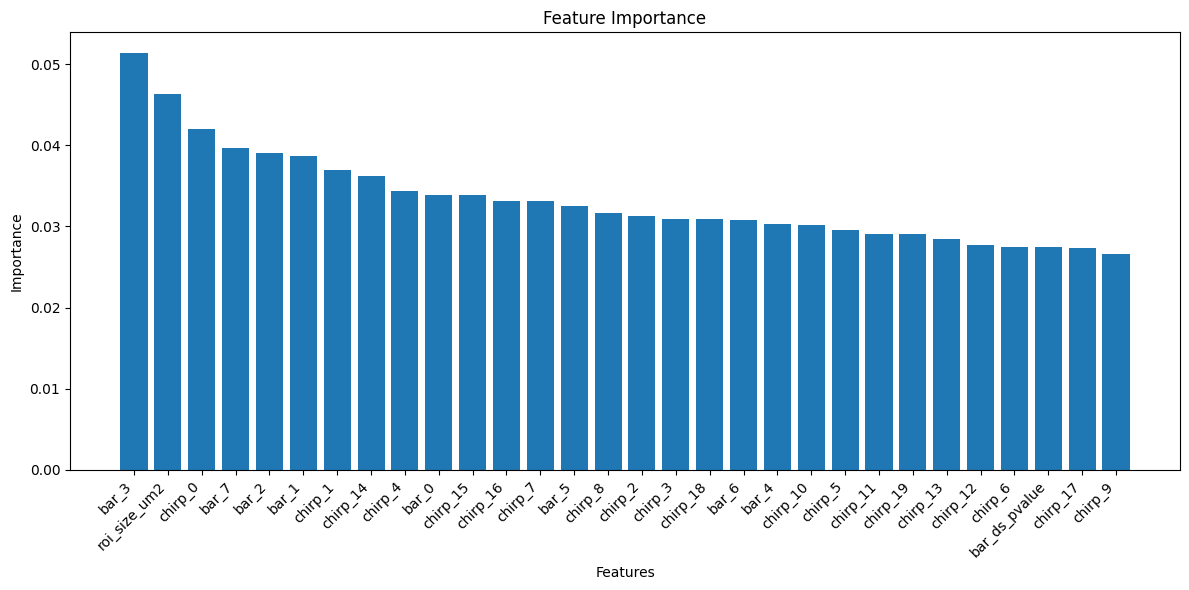

In [24]:
idxs = (experimenter_25 == 'Experimenter 4') | (experimenter_25 == 'Experimenter 3')
check_batch_effects(X=X_25[idxs], y=experimenter_25[idxs], feature_names=feature_names)

While batch effects are quite strong, they are quite strong across all experimenter comparisons.  
The Baden 16 dataset does not seem to be much different from any other dataset.